<a href="https://colab.research.google.com/github/BhagyashreeMohalkar/3D_RNA_Structure_prediction/blob/main/02_dataset_split.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RNA3D-Predict — Dataset Splitting & Leakage Control

This notebook prepares the curated RNA structure dataset for machine learning by creating a reproducible train/validation/test split.

## Objective

The curated dataset produced by `01_dataset_curation.ipynb` contains **536 RNA structures** that satisfy the V1 structural curation criteria.

The purpose of this notebook is to:

1. Load the curated metadata.
2. Group structures with identical RNA sequences.
3. Create a **length-stratified, exact-sequence-group-aware** train/validation/test split.
4. Verify that no identical RNA sequence appears across different splits.
5. Validate the distribution of RNA lengths across the splits.
6. Export the final V1 development split for downstream machine-learning experiments.

## V1 Development Split

The current development split contains:

- **Training:** 426 structures
- **Validation:** 55 structures
- **Test:** 55 structures

The split is designed to prevent **exact sequence leakage** while maintaining a reasonably balanced RNA-length distribution.

## Important Limitation

The V1 development split may still contain highly similar, but non-identical, RNA sequences across different splits.

Therefore, this split is intended for:

- model development
- baseline experiments
- GNN/EGNN experimentation
- initial evaluation
- demo development

A stricter **sequence-cluster-aware split** will be introduced later for research-level generalization analysis.

## Output

This notebook produces:

- `train_v1.csv`
- `validation_v1.csv`
- `test_v1.csv`

These files become the inputs for the graph preprocessing and model-training stages.

In [15]:
# ---------------------------------------------------------
# CELL 1 — Mount Drive and locate the curated dataset
# ---------------------------------------------------------
# Purpose:
#   Mount Google Drive and locate the metadata file exported
#   at the end of Notebook 1.
#
# This notebook uses the curated metadata as its input.
# The raw PDB archive is not processed again here.
# ---------------------------------------------------------

from google.colab import drive
from pathlib import Path

# ---------------------------------------------------------
# Import libraries used throughout Notebook 2
# ---------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Install Biopython for pairwise RNA sequence alignment.
!pip -q install biopython

# Import the alignment tool used for near-duplicate analysis.
from Bio.Align import PairwiseAligner

# Mount Google Drive.
drive.mount("/content/drive")

# Define the main project directory.
PROJECT_DIR = Path(
    "/content/drive/MyDrive/RNA 3D Structure Prediction"
)

# Define the curated dataset directory.
CURATED_DIR = PROJECT_DIR / "Dataset" / "curated"

# Path created by Notebook 1.
CURATED_METADATA_PATH = (
    CURATED_DIR / "curated_metadata_v1.csv"
)

print("Project directory:")
print(PROJECT_DIR)

print("\nCurated metadata:")
print(CURATED_METADATA_PATH)

print("\nFile exists:",
      CURATED_METADATA_PATH.exists())

# Stop immediately if Notebook 1's output is missing.
assert CURATED_METADATA_PATH.exists(), (
    "curated_metadata_v1.csv was not found. "
    "Run the final export cell in Notebook 1 first."
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 17.9 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directory:
/content/drive/MyDrive/RNA 3D Structure Prediction

Curated metadata:
/content/drive/MyDrive/RNA 3D Structure Prediction/Dataset/curated/curated_metadata_v1.csv

File exists: True


In [16]:
# ---------------------------------------------------------
# CELL 2 — Load and validate curated V1 metadata
# ---------------------------------------------------------
# Purpose:
#   Load the 536 curated structures produced by Notebook 1
#   and verify that the expected columns and row count exist.
# ---------------------------------------------------------

# Load the curated metadata.
curated_df = pd.read_csv(
    CURATED_METADATA_PATH
)

print("Dataset shape:", curated_df.shape)

print("\nColumns:")
print(curated_df.columns.tolist())

print("\nFirst 5 rows:")
display(
    curated_df.head()
)

# ---------------------------------------------------------
# Validate the expected dataset size.
# ---------------------------------------------------------

assert len(curated_df) == 536, (
    f"Expected 536 structures, "
    f"but found {len(curated_df)}."
)

# ---------------------------------------------------------
# Validate that every sequence is non-empty.
# ---------------------------------------------------------

assert curated_df["sequence"].notna().all(), (
    "Some sequences are missing."
)

assert (
    curated_df["sequence"].str.len() > 0
).all(), (
    "Some sequences are empty."
)

print("\nValidation: PASSED")

Dataset shape: (536, 17)

Columns:
['sample_id', 'file_name', 'pdb_id', 'model', 'filename_chains', 'pdb_chains', 'num_chains', 'num_residues', 'sequence', 'unique_residue_names', 'nonstandard_residues', 'num_nonstandard_types', 'atom_count', 'P_present', 'C4prime_present', 'P_coverage', 'C4prime_coverage']

First 5 rows:


,sample_id,file_name,pdb_id,model,filename_chains,pdb_chains,num_chains,num_residues,sequence,unique_residue_names,nonstandard_residues,num_nonstandard_types,atom_count,P_present,C4prime_present,P_coverage,C4prime_coverage
0,RNA_0001,PDB_00006WLQ_1_A.pdb,6WLQ,1,A,A,1,118,GUCAUGAGUGCCAGCGUCAAGCCCCGGCUUGCUGGCCGGCAACCCU...,"A,C,G,U",NaN,0,3124,118,118,1.00000,1.0
1,RNA_0002,PDB_00002KX8_1_A.pdb,2KX8,1,A,A,1,42,GGGAAAUGAGGCGCUGCAUGUGGCAGUCUGCCUUUCUUUCCC,"A,C,G,U",NaN,0,1338,41,42,0.97619,1.0
2,RNA_0003,PDB_00008ZAU_1_A.pdb,8ZAU,1,A,A,1,67,GCGGGCUGACCGACCCCCCGAGUUCGCUUGGGGACAACUAGACAUA...,"A,C,G,U",NaN,0,1767,67,67,1.00000,1.0
3,RNA_0004,PDB_00004PQV_1_A.pdb,4PQV,1,A,A,1,68,GGGUCAGAUCGGCGAAAGUCGCCACUUCGCCGAGGAGUGCAAUCUG...,"A,C,G,U",NaN,0,1466,68,68,1.00000,1.0
4,RNA_0005,PDB_00002RRC_1_A.pdb,2RRC,1,A,A,1,20,GACCCCCACGGCGAGGUCCA,"A,C,G,U",NaN,0,533,20,20,1.00000,1.0



Validation: PASSED


In [17]:
# ---------------------------------------------------------
# CELL 3 — Create exact sequence groups
# ---------------------------------------------------------
# Purpose:
#   Assign the same group ID to structures that have exactly
#   the same RNA sequence.
#
# Why:
#   Identical sequences must not be split across train,
#   validation, and test sets, otherwise we can introduce
#   direct sequence leakage.
#
# Important:
#   We are NOT removing duplicate structures.
#   Multiple experimentally determined structures of the
#   same sequence are retained as separate samples.
# ---------------------------------------------------------

# Count how many structures share each exact sequence.
sequence_counts = (
    curated_df["sequence"]
    .value_counts()
)

# Create a mapping:
#     sequence -> exact sequence group ID
#
# The sorted sequence list makes the group IDs deterministic.
unique_sequences = sorted(
    sequence_counts.index
)

sequence_to_group = {
    sequence: f"SEQ_{i:04d}"
    for i, sequence in enumerate(
        unique_sequences,
        start=1
    )
}

# Assign the corresponding group ID to every structure.
curated_df["exact_sequence_group"] = (
    curated_df["sequence"]
    .map(sequence_to_group)
)


# ---------------------------------------------------------
# Validate the grouping
# ---------------------------------------------------------

print("Total structures:",
      len(curated_df))

print(
    "Unique sequences:",
    curated_df["exact_sequence_group"].nunique()
)

print(
    "Exact duplicate groups:",
    (
        sequence_counts > 1
    ).sum()
)

print(
    "Structures belonging to duplicate groups:",
    sequence_counts[
        sequence_counts > 1
    ].sum()
)


# ---------------------------------------------------------
# Show the largest exact-sequence groups.
# ---------------------------------------------------------

group_sizes = (
    curated_df["exact_sequence_group"]
    .value_counts()
)

print("\nLargest exact-sequence groups:")

display(
    group_sizes
    .head(15)
    .rename("structures_in_group")
    .to_frame()
)

Total structures: 536
Unique sequences: 503
Exact duplicate groups: 26
Structures belonging to duplicate groups: 59

Largest exact-sequence groups:


,structures_in_group
exact_sequence_group,
SEQ_0152,6
SEQ_0292,3
SEQ_0158,3
SEQ_0469,3
SEQ_0484,2
SEQ_0024,2
SEQ_0337,2
SEQ_0164,2
SEQ_0413,2


In [18]:
# ---------------------------------------------------------
# CELL 4 — Create a length-stratified group-aware split
# ---------------------------------------------------------
# Purpose:
#   Create the V1 train/validation/test split while satisfying
#   two important constraints:
#
#   1. Exact RNA sequence groups must stay entirely within
#      one split.
#
#   2. RNA-length distributions should be reasonably balanced
#      across the splits.
#
# We split SEQUENCE GROUPS, not individual structures.
#
# Length strata:
#   20–40
#   41–60
#   61–80
#   81–100
#   101–120
#   121–200
#
# The last two original bins (151–175 and 176–200) are
# combined because there are only 18 groups across them.
# ---------------------------------------------------------

from sklearn.model_selection import train_test_split


# ---------------------------------------------------------
# Create one row per exact-sequence group.
# ---------------------------------------------------------
# Each sequence group is treated as one indivisible unit
# during the split.
# ---------------------------------------------------------

group_df = (
    curated_df
    .groupby("exact_sequence_group", as_index=False)
    .agg(
        group_size=("sample_id", "size"),
        sequence_length=("num_residues", "first")
    )
)


# ---------------------------------------------------------
# Create broader length strata for stratified splitting.
# ---------------------------------------------------------

def assign_length_stratum(length):
    """
    Map RNA length to a sufficiently large stratification bin.
    """

    if 20 <= length <= 40:
        return "20–40"

    elif 41 <= length <= 60:
        return "41–60"

    elif 61 <= length <= 80:
        return "61–80"

    elif 81 <= length <= 100:
        return "81–100"

    elif 101 <= length <= 120:
        return "101–120"

    elif 121 <= length <= 200:
        return "121–200"

    else:
        raise ValueError(
            f"Unexpected RNA length: {length}"
        )


group_df["length_stratum"] = (
    group_df["sequence_length"]
    .apply(assign_length_stratum)
)


# ---------------------------------------------------------
# Check how many sequence groups exist in every stratum.
# ---------------------------------------------------------

print("Sequence groups by length stratum:")

display(
    group_df["length_stratum"]
    .value_counts()
    .sort_index()
    .rename("number_of_groups")
    .to_frame()
)


# ---------------------------------------------------------
# First split:
#   80% groups → training
#   20% groups → temporary validation + test
# ---------------------------------------------------------

train_groups_df, temp_groups_df = train_test_split(
    group_df,
    test_size=0.20,
    random_state=42,
    shuffle=True,
    stratify=group_df["length_stratum"]
)


# ---------------------------------------------------------
# Second split:
#   Half of temporary groups → validation
#   Half of temporary groups → test
#
# Stratification is applied again so that validation and
# test remain reasonably similar in RNA-length composition.
# ---------------------------------------------------------

validation_groups_df, test_groups_df = train_test_split(
    temp_groups_df,
    test_size=0.50,
    random_state=42,
    shuffle=True,
    stratify=temp_groups_df["length_stratum"]
)


# ---------------------------------------------------------
# Convert group tables into sets for fast membership tests.
# ---------------------------------------------------------

train_group_ids = set(
    train_groups_df["exact_sequence_group"]
)

validation_group_ids = set(
    validation_groups_df["exact_sequence_group"]
)

test_group_ids = set(
    test_groups_df["exact_sequence_group"]
)


# ---------------------------------------------------------
# Assign every RNA structure to the split of its
# exact-sequence group.
# ---------------------------------------------------------

def assign_split(group_id):
    """Assign a train/validation/test split from a group ID."""

    if group_id in train_group_ids:
        return "train"

    elif group_id in validation_group_ids:
        return "validation"

    elif group_id in test_group_ids:
        return "test"

    else:
        raise ValueError(
            f"Sequence group {group_id} was not assigned."
        )


curated_df["split"] = (
    curated_df["exact_sequence_group"]
    .apply(assign_split)
)


# ---------------------------------------------------------
# Report structure counts.
# ---------------------------------------------------------

print("\nStructure counts by split:")

display(
    curated_df["split"]
    .value_counts()
    .rename("structures")
    .to_frame()
)


print("\nPercentage by split:")

display(
    curated_df["split"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("percentage")
    .to_frame()
)


# ---------------------------------------------------------
# Report sequence-group counts.
# ---------------------------------------------------------

print("\nSequence groups by split:")

display(
    curated_df
    .groupby("split")["exact_sequence_group"]
    .nunique()
    .rename("sequence_groups")
    .to_frame()
)

Sequence groups by length stratum:


,number_of_groups
length_stratum,
101–120,26
121–200,37
20–40,244
41–60,86
61–80,69
81–100,41



Structure counts by split:


,structures
split,
train,426
test,55
validation,55



Percentage by split:


,percentage
split,
train,79.48
test,10.26
validation,10.26



Sequence groups by split:


,sequence_groups
split,
test,51
train,402
validation,50


In [19]:
# ---------------------------------------------------------
# CELL 5 — Verify exact-sequence leakage
# ---------------------------------------------------------
# Purpose:
#   Confirm that no exact RNA sequence group appears in more
#   than one of the train, validation, or test splits.
#
# This is the most important leakage check for our V1 split.
# ---------------------------------------------------------

# Collect sequence groups belonging to each split.
train_groups = set(
    curated_df.loc[
        curated_df["split"] == "train",
        "exact_sequence_group"
    ]
)

validation_groups = set(
    curated_df.loc[
        curated_df["split"] == "validation",
        "exact_sequence_group"
    ]
)

test_groups = set(
    curated_df.loc[
        curated_df["split"] == "test",
        "exact_sequence_group"
    ]
)


# Find overlapping groups between every pair of splits.
train_validation_overlap = (
    train_groups & validation_groups
)

train_test_overlap = (
    train_groups & test_groups
)

validation_test_overlap = (
    validation_groups & test_groups
)


# Report the overlap counts.
print("Train ∩ Validation:",
      len(train_validation_overlap))

print("Train ∩ Test:",
      len(train_test_overlap))

print("Validation ∩ Test:",
      len(validation_test_overlap))


# Fail immediately if any exact sequence crosses splits.
assert len(train_validation_overlap) == 0, (
    "Exact sequence leakage detected between "
    "train and validation."
)

assert len(train_test_overlap) == 0, (
    "Exact sequence leakage detected between "
    "train and test."
)

assert len(validation_test_overlap) == 0, (
    "Exact sequence leakage detected between "
    "validation and test."
)

print("\nExact-sequence leakage check: PASSED")

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

Exact-sequence leakage check: PASSED


RNA length statistics by split:


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,55.0,52.31,36.02,20.0,28.0,36.0,68.0,161.0
train,426.0,54.65,37.25,20.0,27.0,41.0,71.0,200.0
validation,55.0,57.44,40.35,21.0,27.0,41.0,71.5,185.0



Length distribution by split:


split,test,train,validation
length_stratum,,,
20–40,29,211,27
41–60,9,72,9
61–80,7,58,7
81–100,4,33,4
101–120,2,21,3
121–200,4,31,5



Percentage of each split in every length stratum:


split,test,train,validation
length_stratum,,,
20–40,52.73,49.53,49.09
41–60,16.36,16.90,16.36
61–80,12.73,13.62,12.73
81–100,7.27,7.75,7.27
101–120,3.64,4.93,5.45
121–200,7.27,7.28,9.09


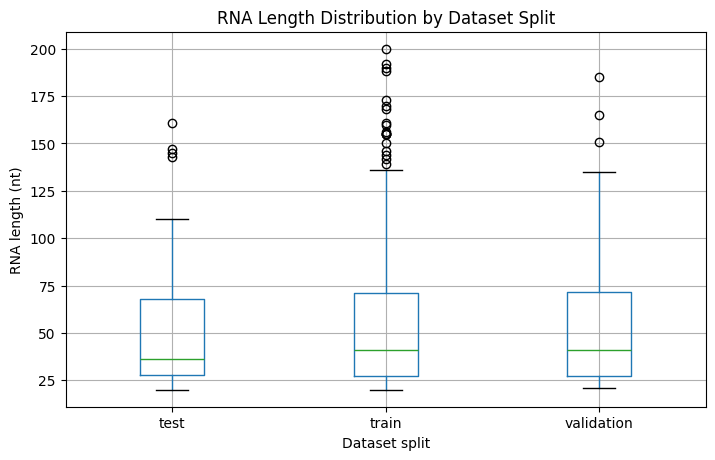

In [20]:
# ---------------------------------------------------------
# CELL 6 — Verify RNA length balance across splits
# ---------------------------------------------------------
# Purpose:
#   Check whether the new length-stratified split provides
#   a reasonable representation of RNA lengths in train,
#   validation, and test.
#
# This cell does NOT modify the split assignments.
# ---------------------------------------------------------

# ---------------------------------------------------------
# Descriptive statistics
# ---------------------------------------------------------

length_summary = (
    curated_df
    .groupby("split")["num_residues"]
    .describe()
    .round(2)
)

print("RNA length statistics by split:")
display(length_summary)


# ---------------------------------------------------------
# Define broad length categories.
# ---------------------------------------------------------
# We use the same six strata used when creating the split.
# ---------------------------------------------------------

length_bins = [19, 40, 60, 80, 100, 120, 200]

length_labels = [
    "20–40",
    "41–60",
    "61–80",
    "81–100",
    "101–120",
    "121–200"
]

# Create a temporary length category for analysis.
curated_df["length_stratum"] = pd.cut(
    curated_df["num_residues"],
    bins=length_bins,
    labels=length_labels,
    include_lowest=True
)


# ---------------------------------------------------------
# Count structures in each length stratum for each split.
# ---------------------------------------------------------

length_distribution = pd.crosstab(
    curated_df["length_stratum"],
    curated_df["split"]
)

print("\nLength distribution by split:")
display(length_distribution)


# ---------------------------------------------------------
# Calculate percentages within each split.
# ---------------------------------------------------------
# This is more informative than raw counts because the
# split sizes are slightly different.
# ---------------------------------------------------------

length_percentage = pd.crosstab(
    curated_df["length_stratum"],
    curated_df["split"],
    normalize="columns"
).mul(100).round(2)

print("\nPercentage of each split in every length stratum:")
display(length_percentage)


# ---------------------------------------------------------
# Visual comparison
# ---------------------------------------------------------

ax = curated_df.boxplot(
    column="num_residues",
    by="split",
    figsize=(8, 5)
)

ax.set_title(
    "RNA Length Distribution by Dataset Split"
)

ax.figure.suptitle("")

ax.set_xlabel("Dataset split")
ax.set_ylabel("RNA length (nt)")

plt.show()

In [21]:
# ---------------------------------------------------------
# CELL 7 — Analyze near-duplicate sequences across splits
# ---------------------------------------------------------
# Purpose:
#   Quantify highly similar RNA sequences that occur in
#   different dataset splits.
#
# We use:
#   identity >= 90%
#   coverage of shorter sequence >= 80%
#   coverage of longer sequence >= 80%
#
# These thresholds are used only as a diagnostic.
# They do NOT automatically define data leakage.
#
# Exact sequence leakage was already verified separately.
# ---------------------------------------------------------

from Bio.Align import PairwiseAligner


# ---------------------------------------------------------
# Create a fresh alignment object.
# ---------------------------------------------------------

aligner = PairwiseAligner()

aligner.mode = "global"
aligner.match_score = 1
aligner.mismatch_score = 0
aligner.open_gap_score = -1
aligner.extend_gap_score = -0.5


# ---------------------------------------------------------
# Function to calculate identity and coverage.
# ---------------------------------------------------------

def compare_sequences(seq1, seq2):
    """
    Align two RNA sequences and calculate:

    identity:
        matching aligned nucleotides /
        aligned nucleotides

    coverage_shorter:
        aligned nucleotides /
        shorter sequence length

    coverage_longer:
        aligned nucleotides /
        longer sequence length
    """

    alignment = aligner.align(
        seq1,
        seq2
    )[0]

    aligned_blocks = alignment.aligned

    matches = 0
    aligned_length = 0

    # Compare each aligned block.
    for (start1, end1), (start2, end2) in zip(
        aligned_blocks[0],
        aligned_blocks[1]
    ):

        block1 = seq1[start1:end1]
        block2 = seq2[start2:end2]

        matches += sum(
            a == b
            for a, b in zip(block1, block2)
        )

        aligned_length += len(block1)

    if aligned_length == 0:
        return 0.0, 0.0, 0.0

    identity = (
        matches / aligned_length
    )

    shorter_length = min(
        len(seq1),
        len(seq2)
    )

    longer_length = max(
        len(seq1),
        len(seq2)
    )

    coverage_shorter = (
        aligned_length / shorter_length
    )

    coverage_longer = (
        aligned_length / longer_length
    )

    return (
        identity,
        coverage_shorter,
        coverage_longer
    )


# ---------------------------------------------------------
# Compare sequences across DIFFERENT splits only.
# ---------------------------------------------------------

split_pairs = [
    ("train", "validation"),
    ("train", "test"),
    ("validation", "test")
]

near_duplicate_results = []

for split_a, split_b in split_pairs:

    # Extract the unique sequences in each split.
    sequences_a = (
        curated_df[
            curated_df["split"] == split_a
        ][
            [
                "sample_id",
                "sequence",
                "pdb_id"
            ]
        ]
        .drop_duplicates("sequence")
        .reset_index(drop=True)
    )

    sequences_b = (
        curated_df[
            curated_df["split"] == split_b
        ][
            [
                "sample_id",
                "sequence",
                "pdb_id"
            ]
        ]
        .drop_duplicates("sequence")
        .reset_index(drop=True)
    )

    print(
        f"\nComparing {split_a} vs {split_b}: "
        f"{len(sequences_a)} × {len(sequences_b)} "
        "unique sequences"
    )

    for i, row_a in sequences_a.iterrows():

        for j, row_b in sequences_b.iterrows():

            identity, coverage_shorter, coverage_longer = (
                compare_sequences(
                    row_a["sequence"],
                    row_b["sequence"]
                )
            )

            # Keep only strong near-duplicate relationships.
            if (
                identity >= 0.90
                and coverage_shorter >= 0.80
                and coverage_longer >= 0.80
            ):

                near_duplicate_results.append({

                    "split_a": split_a,
                    "split_b": split_b,

                    "sample_a": row_a["sample_id"],
                    "sample_b": row_b["sample_id"],

                    "pdb_a": row_a["pdb_id"],
                    "pdb_b": row_b["pdb_id"],

                    "length_a": len(row_a["sequence"]),
                    "length_b": len(row_b["sequence"]),

                    "identity": identity,

                    "coverage_shorter":
                        coverage_shorter,

                    "coverage_longer":
                        coverage_longer
                })


# ---------------------------------------------------------
# Convert results into a DataFrame.
# ---------------------------------------------------------

near_duplicate_df = pd.DataFrame(
    near_duplicate_results
)


# ---------------------------------------------------------
# Report the results.
# ---------------------------------------------------------

print("\n==============================================")
print("CROSS-SPLIT NEAR-DUPLICATE ANALYSIS")
print("==============================================")

print(
    "High-similarity cross-split pairs:",
    len(near_duplicate_df)
)

if len(near_duplicate_df) > 0:

    print("\nPairs by split combination:")

    display(
        near_duplicate_df
        .groupby(
            ["split_a", "split_b"]
        )
        .size()
        .rename("pairs")
        .to_frame()
    )

    print("\nTop cross-split similarities:")

    display(
        near_duplicate_df
        .sort_values(
            ["identity", "coverage_longer"],
            ascending=False
        )
        .head(20)
    )

else:

    print(
        "No cross-split pairs met the diagnostic "
        "near-duplicate threshold."
    )


Comparing train vs validation: 402 × 50 unique sequences

Comparing train vs test: 402 × 51 unique sequences

Comparing validation vs test: 50 × 51 unique sequences

CROSS-SPLIT NEAR-DUPLICATE ANALYSIS
High-similarity cross-split pairs: 62

Pairs by split combination:


pairs
split_a    split_b          
train      test           26
           validation     34
validation test            2


Top cross-split similarities:


,split_a,split_b,sample_a,sample_b,pdb_a,pdb_b,length_a,length_b,identity,coverage_shorter,coverage_longer
0,train,validation,RNA_0001,RNA_0255,6WLQ,6UES,118,119,1.000000,1.000000,0.991597
10,train,validation,RNA_0197,RNA_0173,3SKL,3SKI,64,66,1.000000,1.000000,0.969697
44,train,test,RNA_0183,RNA_0322,2LWK,1JO7,31,30,1.000000,1.000000,0.967742
55,train,test,RNA_0406,RNA_0117,1QD3,1AJU,29,29,1.000000,0.965517,0.965517
19,train,validation,RNA_0363,RNA_0351,9PDF,9PDE,26,27,1.000000,1.000000,0.962963
31,train,validation,RNA_0476,RNA_0390,2CD5,1F7H,27,26,1.000000,1.000000,0.962963
54,train,test,RNA_0400,RNA_0130,1NZ1,2KF0,22,23,1.000000,1.000000,0.956522
8,train,validation,RNA_0154,RNA_0253,1UUI,1LVJ,29,31,1.000000,1.000000,0.935484
60,validation,test,RNA_0253,RNA_0117,1LVJ,1AJU,31,29,1.000000,1.000000,0.935484
38,train,test,RNA_0081,RNA_0117,7JU1,1AJU,28,29,1.000000,0.964286,0.931034


In [22]:
# ---------------------------------------------------------
# CELL 8 — Characterize the cross-split near-duplicates
# ---------------------------------------------------------
# Purpose:
#   Break the 62 cross-split high-similarity pairs into
#   meaningful identity categories.
#
# This helps us determine whether the remaining similarity
# is mostly exact-like sequence duplication or genuinely
# broader near-sequence similarity.
#
# No split assignments are changed in this cell.
# ---------------------------------------------------------

# Count exact alignment-identity relationships.
identity_100 = near_duplicate_df[
    near_duplicate_df["identity"] == 1.0
]

# Count very high but non-identical relationships.
identity_95_999 = near_duplicate_df[
    (near_duplicate_df["identity"] >= 0.95) &
    (near_duplicate_df["identity"] < 1.0)
]

# Count moderate near-duplicates.
identity_90_949 = near_duplicate_df[
    (near_duplicate_df["identity"] >= 0.90) &
    (near_duplicate_df["identity"] < 0.95)
]

print("==============================================")
print("CROSS-SPLIT SIMILARITY BREAKDOWN")
print("==============================================")

print(
    "Total high-similarity pairs:",
    len(near_duplicate_df)
)

print(
    "Identity = 100%:",
    len(identity_100)
)

print(
    "95%–99.99% identity:",
    len(identity_95_999)
)

print(
    "90%–94.99% identity:",
    len(identity_90_949)
)


# ---------------------------------------------------------
# Check how many unique samples participate in these
# relationships.
# ---------------------------------------------------------

def unique_samples_in_pairs(pair_df):
    """Count unique RNA samples appearing in a pair table."""

    if len(pair_df) == 0:
        return 0

    return len(
        set(pair_df["sample_a"]) |
        set(pair_df["sample_b"])
    )


print("\nUnique samples participating:")

print(
    "100% identity:",
    unique_samples_in_pairs(identity_100)
)

print(
    "95%–99.99%:",
    unique_samples_in_pairs(identity_95_999)
)

print(
    "90%–94.99%:",
    unique_samples_in_pairs(identity_90_949)
)


# ---------------------------------------------------------
# Inspect the 100%-identity pairs separately.
# ---------------------------------------------------------
# These are particularly interesting because they may
# represent sequences that differ only by insertions,
# deletions, or alignment gaps.
# ---------------------------------------------------------

print("\nTop 100%-identity cross-split pairs:")

display(
    identity_100
    .sort_values(
        ["coverage_longer", "length_a", "length_b"],
        ascending=False
    )
    [
        [
            "split_a",
            "split_b",
            "sample_a",
            "sample_b",
            "pdb_a",
            "pdb_b",
            "length_a",
            "length_b",
            "identity",
            "coverage_shorter",
            "coverage_longer"
        ]
    ]
    .head(30)
)

CROSS-SPLIT SIMILARITY BREAKDOWN
Total high-similarity pairs: 62
Identity = 100%: 17
95%–99.99% identity: 24
90%–94.99% identity: 21

Unique samples participating:
100% identity: 25
95%–99.99%: 37
90%–94.99%: 38

Top 100%-identity cross-split pairs:


,split_a,split_b,sample_a,sample_b,pdb_a,pdb_b,length_a,length_b,identity,coverage_shorter,coverage_longer
0,train,validation,RNA_0001,RNA_0255,6WLQ,6UES,118,119,1.0,1.000000,0.991597
10,train,validation,RNA_0197,RNA_0173,3SKL,3SKI,64,66,1.0,1.000000,0.969697
44,train,test,RNA_0183,RNA_0322,2LWK,1JO7,31,30,1.0,1.000000,0.967742
55,train,test,RNA_0406,RNA_0117,1QD3,1AJU,29,29,1.0,0.965517,0.965517
31,train,validation,RNA_0476,RNA_0390,2CD5,1F7H,27,26,1.0,1.000000,0.962963
19,train,validation,RNA_0363,RNA_0351,9PDF,9PDE,26,27,1.0,1.000000,0.962963
54,train,test,RNA_0400,RNA_0130,1NZ1,2KF0,22,23,1.0,1.000000,0.956522
60,validation,test,RNA_0253,RNA_0117,1LVJ,1AJU,31,29,1.0,1.000000,0.935484
8,train,validation,RNA_0154,RNA_0253,1UUI,1LVJ,29,31,1.0,1.000000,0.935484
38,train,test,RNA_0081,RNA_0117,7JU1,1AJU,28,29,1.0,0.964286,0.931034


In [23]:
# ---------------------------------------------------------
# CELL 9 — Final V1 split summary
# ---------------------------------------------------------
# Purpose:
#   Create a compact summary of the V1 development split
#   before exporting it.
#
# This split is:
#   - exact-sequence-group aware
#   - length-stratified
#   - free of exact sequence leakage
#
# Note:
#   Near-duplicate relationships can still exist across
#   splits. A stricter sequence-clustered research split
#   will be created later.
# ---------------------------------------------------------

# Count structures in each split.
split_counts = (
    curated_df["split"]
    .value_counts()
    .reindex(
        ["train", "validation", "test"]
    )
)

# Count sequence groups in each split.
group_counts = (
    curated_df
    .groupby("split")["exact_sequence_group"]
    .nunique()
    .reindex(
        ["train", "validation", "test"]
    )
)

# Build the final summary table.
split_summary = pd.DataFrame({
    "structures": split_counts,
    "sequence_groups": group_counts
})

split_summary["percentage"] = (
    split_summary["structures"]
    / len(curated_df)
    * 100
).round(2)

print("==============================================")
print("V1 DEVELOPMENT SPLIT")
print("==============================================")

display(split_summary)

print(
    "\nTotal structures:",
    split_summary["structures"].sum()
)

print(
    "Total sequence groups:",
    split_summary["sequence_groups"].sum()
)

V1 DEVELOPMENT SPLIT


,structures,sequence_groups,percentage
split,,,
train,426,402,79.48
validation,55,50,10.26
test,55,51,10.26



Total structures: 536
Total sequence groups: 503


In [24]:
# ---------------------------------------------------------
# CELL 10 — Export the frozen V1 dataset splits
# ---------------------------------------------------------
# Purpose:
#   Save the finalized V1 train, validation, and test metadata
#   as separate CSV files.
#
# These files become the stable inputs for future ML notebooks.
#
# We remove temporary analysis columns such as:
#   - length_group
#   - length_stratum
#
# We retain:
#   - sample metadata
#   - sequence
#   - exact sequence group
#   - split assignment
#
# No structural data is modified here.
# ---------------------------------------------------------

# Define the columns that belong in the ML split metadata.
export_columns = [
    "sample_id",
    "file_name",
    "pdb_id",
    "model",
    "filename_chains",
    "pdb_chains",
    "num_chains",
    "num_residues",
    "sequence",
    "unique_residue_names",
    "nonstandard_residues",
    "num_nonstandard_types",
    "atom_count",
    "P_present",
    "C4prime_present",
    "P_coverage",
    "C4prime_coverage",
    "exact_sequence_group",
    "split"
]

# Create the final export dataframe.
split_metadata = curated_df[
    export_columns
].copy()


# ---------------------------------------------------------
# Create output directory.
# ---------------------------------------------------------

SPLITS_DIR = (
    PROJECT_DIR
    / "Dataset"
    / "splits"
)

SPLITS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ---------------------------------------------------------
# Create separate train/validation/test dataframes.
# ---------------------------------------------------------

train_df = split_metadata[
    split_metadata["split"] == "train"
].copy()

validation_df = split_metadata[
    split_metadata["split"] == "validation"
].copy()

test_df = split_metadata[
    split_metadata["split"] == "test"
].copy()


# ---------------------------------------------------------
# Define output paths.
# ---------------------------------------------------------

TRAIN_PATH = SPLITS_DIR / "train_v1.csv"
VALIDATION_PATH = SPLITS_DIR / "validation_v1.csv"
TEST_PATH = SPLITS_DIR / "test_v1.csv"


# ---------------------------------------------------------
# Save the split files.
# ---------------------------------------------------------

train_df.to_csv(
    TRAIN_PATH,
    index=False
)

validation_df.to_csv(
    VALIDATION_PATH,
    index=False
)

test_df.to_csv(
    TEST_PATH,
    index=False
)


# ---------------------------------------------------------
# Report the exported files.
# ---------------------------------------------------------

print("V1 split files saved successfully.\n")

print("Train:")
print(TRAIN_PATH)
print("Rows:", len(train_df))

print("\nValidation:")
print(VALIDATION_PATH)
print("Rows:", len(validation_df))

print("\nTest:")
print(TEST_PATH)
print("Rows:", len(test_df))

V1 split files saved successfully.

Train:
/content/drive/MyDrive/RNA 3D Structure Prediction/Dataset/splits/train_v1.csv
Rows: 426

Validation:
/content/drive/MyDrive/RNA 3D Structure Prediction/Dataset/splits/validation_v1.csv
Rows: 55

Test:
/content/drive/MyDrive/RNA 3D Structure Prediction/Dataset/splits/test_v1.csv
Rows: 55


In [25]:
# ---------------------------------------------------------
# CELL 11 — Reload and verify the exported V1 splits
# ---------------------------------------------------------
# Purpose:
#   Reload train, validation, and test CSV files directly
#   from Google Drive and verify that the saved artifacts
#   match the split we created in memory.
#
# Why:
#   This confirms that the exported files are usable
#   independently of the current Colab session.
#
# This is our final checkpoint for Notebook 2.
# ---------------------------------------------------------

# ---------------------------------------------------------
# Reload the three saved split files from disk.
# ---------------------------------------------------------

train_check = pd.read_csv(TRAIN_PATH)
validation_check = pd.read_csv(VALIDATION_PATH)
test_check = pd.read_csv(TEST_PATH)


# ---------------------------------------------------------
# Check the number of rows in each file.
# ---------------------------------------------------------

print("=== ROW COUNTS ===")

print("Train:", len(train_check))
print("Validation:", len(validation_check))
print("Test:", len(test_check))

print(
    "Total:",
    len(train_check)
    + len(validation_check)
    + len(test_check)
)


# ---------------------------------------------------------
# Verify the expected split sizes.
# ---------------------------------------------------------

assert len(train_check) == 426, (
    "Unexpected number of training structures."
)

assert len(validation_check) == 55, (
    "Unexpected number of validation structures."
)

assert len(test_check) == 55, (
    "Unexpected number of test structures."
)


# ---------------------------------------------------------
# Verify that every sample appears in exactly one split.
# ---------------------------------------------------------

train_ids = set(train_check["sample_id"])
validation_ids = set(validation_check["sample_id"])
test_ids = set(test_check["sample_id"])

assert len(
    train_ids & validation_ids
) == 0, "Sample overlap between train and validation."

assert len(
    train_ids & test_ids
) == 0, "Sample overlap between train and test."

assert len(
    validation_ids & test_ids
) == 0, "Sample overlap between validation and test."


# ---------------------------------------------------------
# Verify exact sequence groups do not cross splits.
# ---------------------------------------------------------

train_sequence_groups = set(
    train_check["exact_sequence_group"]
)

validation_sequence_groups = set(
    validation_check["exact_sequence_group"]
)

test_sequence_groups = set(
    test_check["exact_sequence_group"]
)

assert len(
    train_sequence_groups & validation_sequence_groups
) == 0, "Sequence-group leakage detected."

assert len(
    train_sequence_groups & test_sequence_groups
) == 0, "Sequence-group leakage detected."

assert len(
    validation_sequence_groups & test_sequence_groups
) == 0, "Sequence-group leakage detected."


# ---------------------------------------------------------
# Verify that all rows together recover the original
# 536 curated structures.
# ---------------------------------------------------------

combined_ids = (
    train_ids
    | validation_ids
    | test_ids
)

assert len(combined_ids) == 536, (
    "The exported splits do not contain all 536 structures."
)


# ---------------------------------------------------------
# Final verification message.
# ---------------------------------------------------------

print("\n==============================================")
print("V1 SPLIT VERIFICATION")
print("==============================================")

print("Row-count check: PASSED")
print("Sample-overlap check: PASSED")
print("Exact-sequence-group leakage check: PASSED")
print("Total structure coverage check: PASSED")

print("\nNotebook 2 V1 split artifacts are valid.")

=== ROW COUNTS ===
Train: 426
Validation: 55
Test: 55
Total: 536

V1 SPLIT VERIFICATION
Row-count check: PASSED
Sample-overlap check: PASSED
Exact-sequence-group leakage check: PASSED
Total structure coverage check: PASSED

Notebook 2 V1 split artifacts are valid.


# Dataset Splitting — Conclusion

The curated V1 dataset contains 536 RNA structures and 503 unique exact RNA sequences.

A length-stratified, exact-sequence-group-aware development split was created:

- **Training:** 426 structures
- **Validation:** 55 structures
- **Test:** 55 structures

The split was validated for:
- No sample overlap between splits
- No exact-sequence-group leakage
- Complete coverage of all 536 curated structures

### Important limitation

The V1 development split can still contain highly similar, but non-identical, RNA sequences across different splits. Pairwise analysis identified 62 high-similarity cross-split relationships under the diagnostic threshold used during analysis.

Therefore, this split is intended for **model development, experimentation, and the initial demonstration**.

A stricter sequence-cluster-aware split will be introduced later as part of the research/generalization evaluation.

## Next stage

The next notebook will convert the curated RNA structures into machine-learning-ready graph representations.